# BDA 602 Final Project: K-Means Clustering (Unsupervised Learning)
**Get It Done Crew** · Section owner: Emerson Ceccarelli

**Goal:** group closed 2025 Get It Done requests by shared characteristics (request type, geography, timing) and check whether the groups differ in resolution time (`case_age_days`). Clusters are then exported as a candidate feature for the linear and logistic regression models.

**Plan (matches the paper draft's K-Means section):**
1. Load data and repeat the team's shared preprocessing (same as `BDA602_EDA.ipynb`)
2. Build the clustering feature set (one-hot categoricals + scaled numerics)
3. Choose *k* with the Elbow method and Silhouette score
4. Fit the final model and profile each cluster
5. Validate: do clusters differ on `case_age_days` (ANOVA / Kruskal-Wallis) and request type (chi-square)?
6. Optional part B: neighborhood-level clustering by request-type mix (Wang et al., 2017)
7. Export cluster labels for the supervised models

## 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, gdown, warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy import stats

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

## 1. Load data
Same Google Drive file as the EDA notebook. Skips the download if the CSV is already in the Colab session.

In [ ]:
gid_path = "1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY"
csv_name = "get_it_done_requests_closed_2025_datasd.csv"

if not os.path.exists(csv_name):
    gdown.download(id=gid_path, output=csv_name, quiet=False)

gid_requests = pd.read_csv(csv_name)
gid_requests.shape

Downloading...
From (original): https://drive.google.com/uc?id=1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY
From (redirected): https://drive.google.com/uc?id=1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY&confirm=t&uuid=720cedbb-0221-40e7-92ce-7116f3713a75
To: /content/get_it_done_requests_closed_2025_datasd.csv
100%|██████████| 128M/128M [00:01<00:00, 77.6MB/s]


(378669, 23)

## 2. Shared preprocessing (copied from `BDA602_EDA.ipynb`)
Kept identical to the team's notebook so the clusters line up row-for-row with the regression data:
- strip trailing `.0` from zipcode / comm_plan_code / council_district
- keep only `status == "Closed"` (drop Referred)
- keep the 12 ML columns and drop rows missing service_name, zipcode, council_district, comm_plan_code
- engineer date parts and `urgent_language`

In [ ]:
for col in ["zipcode", "comm_plan_code", "council_district"]:
    gid_requests[col] = gid_requests[col].astype(str).str.replace(r"\.0$", "", regex=True)

closed_requests = gid_requests[gid_requests["status"] == "Closed"].copy()

ml_df = closed_requests[[
    "service_request_id", "case_age_days", "date_requested", "date_closed",
    "case_record_type", "service_name", "zipcode", "council_district",
    "comm_plan_code", "comm_plan_name", "case_origin", "public_description"
]]
ml_df = ml_df.dropna(subset=["service_name", "zipcode", "council_district", "comm_plan_code"]).reset_index(drop=True)

# Date features
ml_df["date_requested"] = pd.to_datetime(ml_df["date_requested"])
ml_df["date_closed"] = pd.to_datetime(ml_df["date_closed"])
ml_df["request_year"] = ml_df["date_requested"].dt.year
ml_df["request_month"] = ml_df["date_requested"].dt.month
ml_df["request_day_of_week"] = ml_df["date_requested"].dt.dayofweek
ml_df["request_quarter"] = ml_df["date_requested"].dt.quarter

days_to_close = (ml_df["date_closed"] - ml_df["date_requested"]).dt.days
ml_df["closed_within_30_days"] = (days_to_close <= 30).astype(int)

# Urgency flag
urgency_terms = ["urgent", "urgently", "emergency", "immediately", "immediate", "asap",
                 "danger", "dangerous", "hazard", "hazardous", "unsafe", "critical"]
ml_df["urgent_language"] = (
    ml_df["public_description"].fillna("").str.contains("|".join(urgency_terms), case=False, na=False).astype(int)
)

ml_df = ml_df.drop(columns=["public_description", "date_requested", "date_closed"])
print(ml_df.shape)   # EDA notebook gets (350694, ...)
ml_df.head()

(350694, 15)


,service_request_id,case_age_days,case_record_type,service_name,zipcode,council_district,comm_plan_code,comm_plan_name,case_origin,request_year,request_month,request_day_of_week,request_quarter,closed_within_30_days,urgent_language
0,5152705,1,ESD Complaint/Report,Missed Collection,92109,2,18,MISSION BEACH,Web,2025,3,2,1,1,0
1,5152711,27,Parking,Parking Violation,92117,2,6,CLAIREMONT MESA,Web,2025,3,2,1,1,1
2,5152712,14,Neighborhood Policing,Encampment,92101,2,14,MIDWAY-PACIFIC HIGHWAY,Web,2025,3,2,1,1,0
3,5152714,3,Parking,Parking Violation,92110,2,6,CLAIREMONT MESA,Web,2025,3,2,1,1,0
4,5152728,5,ESD Complaint/Report,Missed Collection,92113,8,37,SOUTHEASTERN SAN DIEGO,Web,2025,3,2,1,1,0


The team's `kmeans_df` drops both outcome columns. We keep `case_age_days` and `closed_within_30_days` in a separate frame so we can **profile** clusters with them afterwards without using them to **build** the clusters.

In [ ]:
kmeans_df = ml_df.drop(columns=["closed_within_30_days", "case_age_days"])
outcomes = ml_df[["service_request_id", "case_age_days", "closed_within_30_days"]]
kmeans_df.shape

(350694, 13)

## 3. Feature set for clustering

**Decision points (edit the lists below):**

- **Leave `case_age_days` out of the clustering features (default).** The paper draft lists it as a candidate feature. But if cluster labels are later fed into the linear/logistic models, clusters built from the outcome would leak the target. Clustering without it and *then* checking whether clusters differ in resolution time is the cleaner test. Set `INCLUDE_CASE_AGE = True` to try the other version (it is log-transformed first because of the heavy right skew).
- **Pick one geography.** zipcode, comm_plan_code, comm_plan_name, and council_district all describe location. One-hot encoding all of them would give geography several times the weight of request type in the distance calculation. The default uses `council_district` only (10 levels). Swap in `comm_plan_code` for finer detail.
- **Numeric features are standardized** (StandardScaler) since k-means uses Euclidean distance.

In [ ]:
INCLUDE_CASE_AGE = False

# Everything is put on the same 0/1 scale so no single feature dominates the distances
categorical_features = ["service_name", "council_district", "case_origin",
                        "request_month", "request_day_of_week"]
binary_features = ["urgent_language"]          # already 0/1, so it is NOT standardized

X = kmeans_df[categorical_features + binary_features].copy()
X[["request_month", "request_day_of_week"]] = X[["request_month", "request_day_of_week"]].astype(str)

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
transformers = [
    ("cat", cat_pipe, categorical_features),
    ("bin", "passthrough", binary_features),
]
if INCLUDE_CASE_AGE:
    X["log_case_age"] = np.log1p(ml_df["case_age_days"].clip(lower=0))
    transformers.append(("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                                          ("scaler", StandardScaler())]), ["log_case_age"]))

preprocessor = ColumnTransformer(transformers)
X_prep = preprocessor.fit_transform(X).astype(np.float32)
feature_names = preprocessor.get_feature_names_out()
print("Matrix shape:", X_prep.shape)

Matrix shape: (350694, 92)


## 4. Choosing k: Elbow and Silhouette
- **Inertia** (within-cluster sum of squares) always drops as k grows; look for the bend.
- **Silhouette** ranges from −1 to 1, higher is better. Computing it on all ~350k rows is O(n²), so it is scored on a fixed random sample of 10,000 rows.
- **Davies-Bouldin** (lower is better) is included as a tie-breaker.

In [ ]:
K_RANGE = range(2, 13)
SIL_SAMPLE = min(10_000, X_prep.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
sil_idx = rng.choice(X_prep.shape[0], SIL_SAMPLE, replace=False)

results = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_prep)
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_prep[sil_idx], labels[sil_idx]),
        "davies_bouldin": davies_bouldin_score(X_prep[sil_idx], labels[sil_idx]),
    })
    print(f"k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={results[-1]['silhouette']:.3f}")

k_results = pd.DataFrame(results)
k_results

k= 2  inertia=1,351,811  silhouette=0.088
k= 3  inertia=1,259,955  silhouette=0.112
k= 4  inertia=1,213,530  silhouette=0.123
k= 5  inertia=1,185,594  silhouette=0.085
k= 6  inertia=1,144,151  silhouette=0.090
k= 7  inertia=1,136,009  silhouette=0.079
k= 8  inertia=1,099,235  silhouette=0.098
k= 9  inertia=1,078,238  silhouette=0.098
k=10  inertia=1,065,292  silhouette=0.095
k=11  inertia=1,058,438  silhouette=0.076
k=12  inertia=1,034,776  silhouette=0.099


,k,inertia,silhouette,davies_bouldin
0,2,1351810.625,0.087871,3.234325
1,3,1259954.625,0.111769,2.792431
2,4,1213530.500,0.123052,2.785347
3,5,1185593.500,0.085057,3.265878
4,6,1144151.375,0.089984,3.013962
5,7,1136009.125,0.079295,3.080349
6,8,1099234.750,0.097695,3.027576
7,9,1078238.375,0.097774,2.779581
8,10,1065291.750,0.095185,3.023190
9,11,1058437.875,0.075582,3.070888


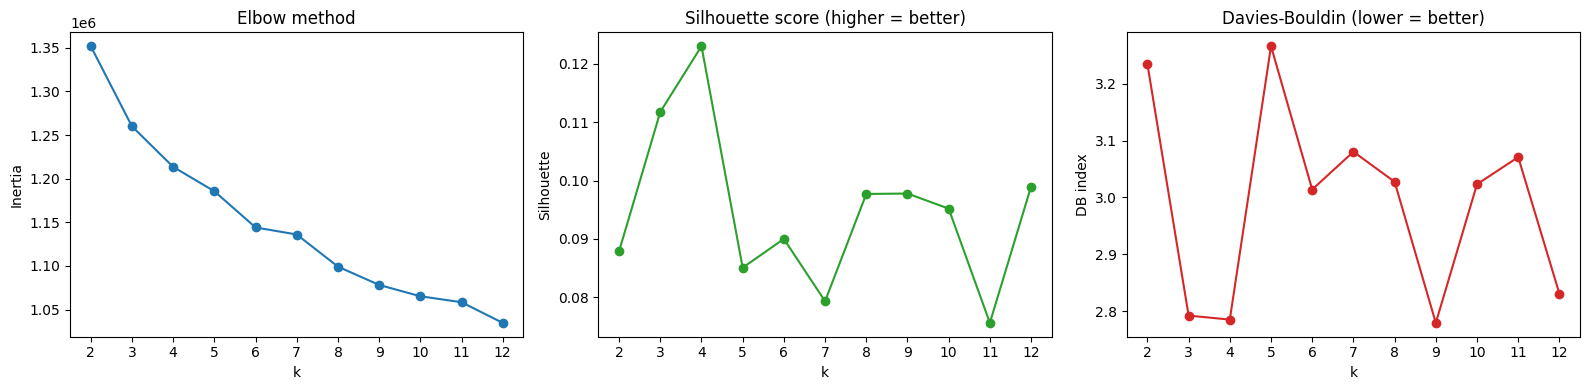

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(k_results["k"], k_results["inertia"], marker="o")
axes[0].set(title="Elbow method", xlabel="k", ylabel="Inertia")
axes[1].plot(k_results["k"], k_results["silhouette"], marker="o", color="tab:green")
axes[1].set(title="Silhouette score (higher = better)", xlabel="k", ylabel="Silhouette")
axes[2].plot(k_results["k"], k_results["davies_bouldin"], marker="o", color="tab:red")
axes[2].set(title="Davies-Bouldin (lower = better)", xlabel="k", ylabel="DB index")
for ax in axes: ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

**Choose k:** look at the elbow and silhouette plots, then set `FINAL_K` below. Write one or two sentences here for the paper explaining the choice (e.g., "inertia flattens after k = _ and silhouette peaks at k = _").

In [ ]:
FINAL_K = 4
# print("FINAL_K =", FINAL_K)

kmeans = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE)
ml_df["cluster"] = kmeans.fit_predict(X_prep)
ml_df["cluster"].value_counts().sort_index()

,count
cluster,
0,40503
1,84089
2,176595
3,49507


### Choosing k = 4

K-means was run for k = 2 through 12, and each result was scored three ways. Silhouette and Davies-Bouldin were computed on the same random sample of 10,000 requests for every k.

| k | Inertia | Drop from previous k | Silhouette (higher = better) | Davies-Bouldin (lower = better) |
|---|---|---|---|---|
| 2 | 1,351,811 | – | 0.088 | 3.234 |
| 3 | 1,259,955 | 91,856 | 0.112 | 2.792 |
| **4** | **1,213,530** | **46,425** | **0.123** | **2.785** |
| 5 | 1,185,594 | 27,937 | 0.085 | 3.266 |
| 6 | 1,144,151 | 41,442 | 0.090 | 3.014 |
| 7 | 1,136,009 | 8,142 | 0.079 | 3.080 |
| 8 | 1,099,235 | 36,774 | 0.098 | 3.028 |
| 9 | 1,078,238 | 20,997 | 0.098 | 2.780 |
| 10 | 1,065,292 | 12,946 | 0.095 | 3.023 |
| 11 | 1,058,438 | 6,854 | 0.076 | 3.071 |
| 12 | 1,034,776 | 23,662 | 0.099 | 2.831 |

**Why k = 4:**
- **Elbow (inertia):** Inertia is the total distance from each request to the center of its cluster, so lower means tighter clusters. It always falls as k increases, so the goal is to find where the improvement levels off. The largest drops come from k = 2 to 3 (−91,856) and from 3 to 4 (−46,425). After k = 4 the gains are smaller and uneven, so k = 4 sits at the bend of the curve.
- **Silhouette:** This score measures how clearly each request belongs to its own cluster rather than the nearest other cluster. It peaks at k = 4 (0.123), then drops and stays between 0.08 and 0.10.
- **Davies-Bouldin:** This index compares how spread out each cluster is with how far it is from its nearest neighboring cluster. k = 4 (2.785) is effectively tied with k = 9 (2.780) for the lowest value. Because the simpler model scores just as well, k = 4 is preferred.

**Caveat:** A silhouette of 0.12 is low. The four clusters overlap considerably, and many requests sit near the border between two clusters. This is expected when the features are mostly one-hot encoded (yes/no) columns. The clusters should be read as broad tendencies rather than sharply separated groups.

**Note on an earlier run:** The first version of the feature set standardized the 0/1 `urgent_language` flag. Because only about 4% of requests contain urgency language, standardizing gave that one flag an outsized effect on the distance calculation. The result was k = 2 with a misleading silhouette of 0.50, and the two clusters exactly matched urgent vs. non-urgent requests (14,505 vs. 336,189). Leaving the flag as a plain 0/1 and one-hot encoding month and day of week fixed this.

**Final cluster sizes (k = 4, n = 350,694):**

| Cluster | Requests | Share |
|---|---|---|
| 0 | 40,503 | 11.5% |
| 1 | 84,089 | 24.0% |
| 2 | 176,595 | 50.4% |
| 3 | 49,507 | 14.1% |

## 5. Cluster profiles
For each cluster: size, dominant request types, dominant geography, and resolution time.

In [ ]:
def top_share(s, n=3):
    vc = s.value_counts(normalize=True).head(n)
    return ", ".join(f"{i} ({v:.0%})" for i, v in vc.items())

profile = ml_df.groupby("cluster").agg(
    n_requests=("service_request_id", "size"),
    median_case_age=("case_age_days", "median"),
    mean_case_age=("case_age_days", "mean"),
    pct_closed_30d=("closed_within_30_days", "mean"),
    pct_urgent=("urgent_language", "mean"),
)
profile["share_of_data"] = profile["n_requests"] / profile["n_requests"].sum()
profile["top_service_names"] = ml_df.groupby("cluster")["service_name"].apply(top_share)
profile["top_districts"] = ml_df.groupby("cluster")["council_district"].apply(top_share)
profile["top_case_origin"] = ml_df.groupby("cluster")["case_origin"].apply(lambda s: top_share(s, 2))

profile.style.format({
    "share_of_data": "{:.1%}", "pct_closed_30d": "{:.1%}", "pct_urgent": "{:.1%}",
    "mean_case_age": "{:.1f}", "median_case_age": "{:.0f}", "n_requests": "{:,}"
})

,n_requests,median_case_age,mean_case_age,pct_closed_30d,pct_urgent,share_of_data,top_service_names,top_districts,top_case_origin
cluster,,,,,,,,,
0,"40,503",1,28.4,92.0%,1.1%,11.5%,"Graffiti - Public (30%), Missed Collection (26%), ESD Collections (8%)","3 (21%), 9 (15%), 4 (13%)","Phone (61%), Crew/Self Generated (32%)"
1,"84,089",4,51.9,80.0%,6.4%,24.0%,"Parking Violation (33%), Missed Collection (22%), Encampment (9%)","2 (18%), 3 (16%), 9 (14%)","Web (100%), CC Self Generate (0%)"
2,"176,595",6,66.2,77.2%,4.9%,50.4%,"Parking Violation (25%), Encampment (17%), Illegal Dumping (10%)","3 (26%), 9 (18%), 2 (14%)","Mobile (100%), CC Self Generate (0%)"
3,"49,507",0,0.4,99.9%,0.0%,14.1%,"Illegal Dumping (99%), Environmental Services Code Compliance (0%), Dead Animal (0%)","9 (27%), 8 (17%), 3 (15%)","Worker App (99%), CC Self Generate (1%)"


### Cluster profiles (k = 4)

| Cluster | Label | Share | Dominant channel | Dominant request types | Median / mean days | Closed ≤30 days |
|---|---|---|---|---|---|---|
| 3 | Worker-logged dumping | 14.1% | Worker App (99%) | Illegal Dumping (99%) | 0 / 0.4 | 99.9% |
| 0 | Phone & crew reports | 11.5% | Phone (61%), Crew/Self Generated (32%) | Graffiti – Public (30%), Missed Collection (26%) | 1 / 28.4 | 92.0% |
| 1 | Web reports | 24.0% | Web (100%) | Parking Violation (33%), Missed Collection (22%), Encampment (9%) | 4 / 51.9 | 80.0% |
| 2 | Mobile app reports | 50.4% | Mobile (100%) | Parking Violation (25%), Encampment (17%), Illegal Dumping (10%) | 6 / 66.2 | 77.2% |

**Interpretation:**
- **Submission channel is the main source of structure.** Clusters 1 and 2 are each made up entirely of one channel (Web and Mobile) and have similar request-type mixes.
- **Geography does not separate the clusters.** Council districts 3, 9 and 2 are among the top districts in nearly every cluster, so no cluster corresponds to a distinct part of the city.
- **Resolution time differs sharply across clusters**, even though case age was not used to build them. Cluster 3 is almost entirely illegal dumping logged and closed by city staff in the Worker App, so it reflects completed work rather than resident requests waiting for service. Resident-submitted Web and Mobile requests (clusters 1 and 2) take the longest, with medians of 4–6 days and long right tails (means of 52–66 days).
- **Implication for the supervised models:** Staff-generated cases (Worker App, Crew/Self Generated) close almost immediately and may inflate the predictive power of `case_origin`. The team may want to test the regression models with and without these cases.

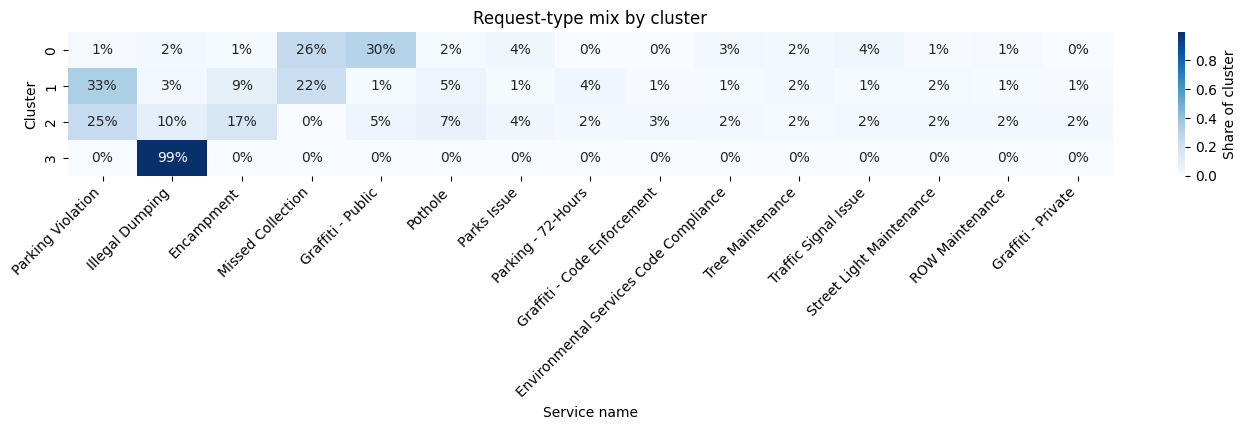

In [ ]:
# Request-type mix within each cluster (top 15 service names overall)
top_services = ml_df["service_name"].value_counts().head(15).index
mix = pd.crosstab(ml_df["cluster"], ml_df["service_name"], normalize="index")[top_services]

plt.figure(figsize=(14, 0.6 * FINAL_K + 2))
sns.heatmap(mix, cmap="Blues", annot=True, fmt=".0%", cbar_kws={"label": "Share of cluster"})
plt.title("Request-type mix by cluster")
plt.xlabel("Service name"); plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

### Request-type mix by cluster

The heatmap shows what share of each cluster comes from each of the 15 most common request types. Rows do not sum to 100% because less common request types are not shown.

- **Cluster 3** is almost entirely Illegal Dumping (99%), consistent with its Worker App origin.
- **Cluster 0** is concentrated in Graffiti – Public (30%) and Missed Collection (26%), with almost no parking requests (1%). These are request types frequently reported by phone or generated by city crews.
- **Clusters 1 and 2** are broad mixes of resident-submitted complaints, led by Parking Violation (33% and 25%). They differ mainly in Missed Collection (22% of Web reports vs. 0% of Mobile reports) and in Encampment (9% vs. 17%) and Illegal Dumping (3% vs. 10%), which appear more often in Mobile reports. The absence of Missed Collection among Mobile reports may reflect how the mobile app categorizes or routes trash issues rather than resident behavior.
- No cluster is defined by Pothole requests, which make up 7% or less of every cluster.

Overall, two clusters are defined by a narrow set of request types (0 and 3), while the two largest clusters (1 and 2) are defined more by submission channel than by request type.

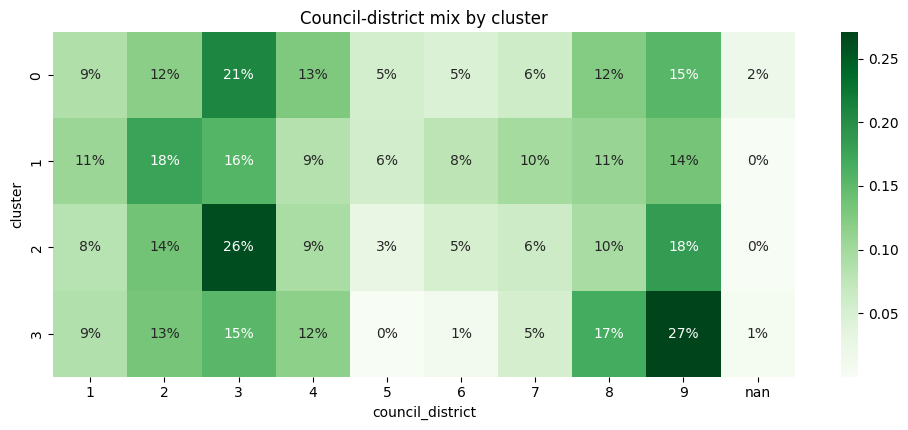

In [ ]:
# Council-district mix within each cluster
dist_mix = pd.crosstab(ml_df["cluster"], ml_df["council_district"], normalize="index")
plt.figure(figsize=(10, 0.6 * FINAL_K + 2))
sns.heatmap(dist_mix, cmap="Greens", annot=True, fmt=".0%")
plt.title("Council-district mix by cluster")
plt.tight_layout(); plt.show()

### Council-district mix by cluster

Each row shows how a cluster's requests are distributed across council districts (rows sum to 100%).

- **Clusters 0, 1 and 2 have broadly similar geographic distributions.** Districts 3, 9 and 2 are among the largest shares in each, and districts 5 and 6 are small in each. This largely reflects overall request volume by district rather than cluster-specific geography.
- **Cluster 3 (Worker App illegal dumping) is the exception.** It is concentrated in District 9 (27%) and District 8 (17%), with almost no cases in Districts 5 (0%) and 6 (1%). Staff-logged dumping cleanup is therefore geographically uneven. This data cannot tell us whether that reflects where dumping occurs or where crews are deployed.
- Overall, geography separates only one cluster, and that cluster is already defined by request type and submission channel. This is consistent with the profile table: **channel and request type drive the clustering more than location.**

*Note:* The "nan" column represents a small number of requests (about 1–2% of clusters 0 and 3) with no recorded council district. These were retained because of a preprocessing issue in which missing values were converted to the text "nan" before missing rows were dropped.

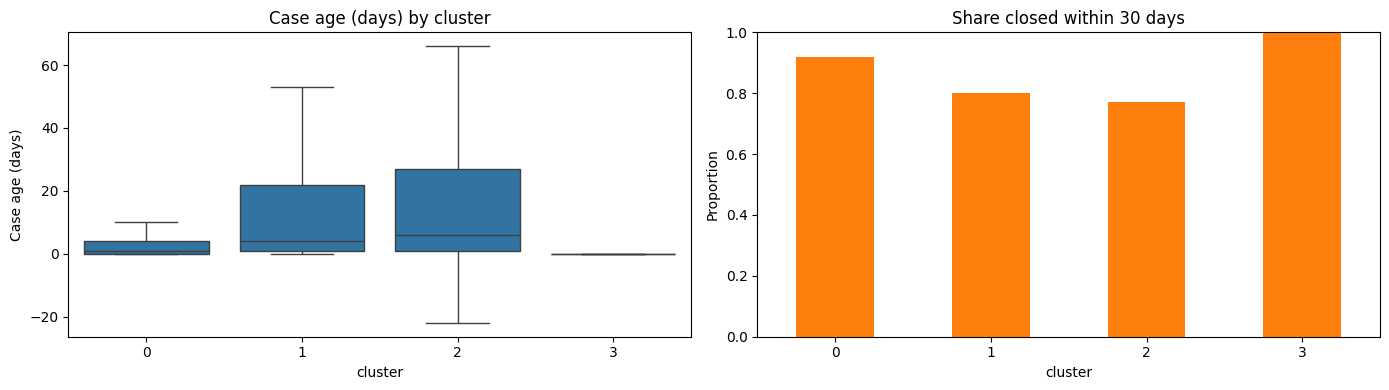

In [ ]:
# Resolution time by cluster (outliers hidden for readability, same as EDA)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=ml_df, x="cluster", y="case_age_days", showfliers=False, ax=axes[0])
axes[0].set(title="Case age (days) by cluster", ylabel="Case age (days)")
profile["pct_closed_30d"].plot(kind="bar", ax=axes[1], color="tab:orange")
axes[1].set(title="Share closed within 30 days", ylabel="Proportion", ylim=(0, 1))
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

### Resolution time by cluster

The left panel shows the distribution of `case_age_days` within each cluster (the line marks the median, the box spans the middle 50% of cases, and extreme outliers are hidden for readability). The right panel shows the share of each cluster's requests closed within 30 days.

| Cluster | Middle 50% of cases | Median days | Closed ≤30 days |
|---|---|---|---|
| 3 – Worker App illegal dumping | ~0 | 0 | 99.9% |
| 0 – Phone & crew | ~0–4 days | 1 | 92.0% |
| 1 – Web reports | ~0–22 days | 4 | 80.0% |
| 2 – Mobile app reports | ~0–27 days | 6 | 77.2% |

- Although `case_age_days` was **not** used to build the clusters, resolution time differs systematically across them. Staff-generated work (clusters 3 and 0) closes fastest, and resident-submitted Web and Mobile requests (clusters 1 and 2) take the longest.
- Clusters 1 and 2 also show much greater **variability**. Their middle 50% spans roughly three to four weeks, compared with a few days for cluster 0, so resident-submitted requests are both slower and less predictable.
- The 30-day share differs less dramatically (77–100%) because most requests in every cluster close within a month. The differences between clusters are concentrated in the slow tail.

*Note:* The lower whisker for cluster 2 extends below zero because of a small number of records (4 in the full dataset) with negative `case_age_days`, where the recorded close date is before the request date. These are data-entry errors that were flagged in EDA but not removed.

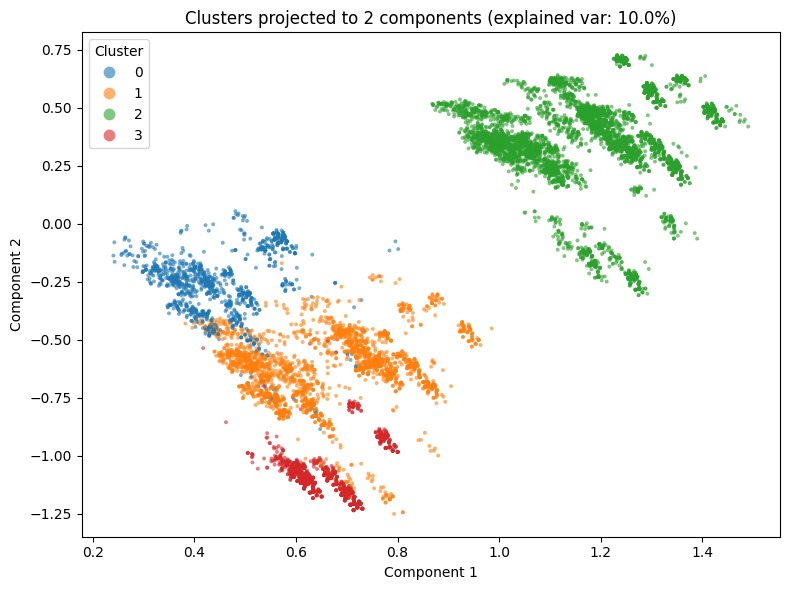

In [ ]:
# 2-D view of the clusters (TruncatedSVD on a 10k sample)
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd.fit_transform(X_prep[sil_idx])
plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=ml_df["cluster"].values[sil_idx],
                palette="tab10", s=8, alpha=0.6, linewidth=0)
plt.title(f"Clusters projected to 2 components (explained var: {svd.explained_variance_ratio_.sum():.1%})")
plt.xlabel("Component 1"); plt.ylabel("Component 2"); plt.legend(title="Cluster", markerscale=3)
plt.tight_layout(); plt.show()

### 2-D view of the clusters

To visualize the clusters, the ~90 encoded features were compressed into two components using Truncated SVD (a PCA variant suited to one-hot encoded data). Each point is one request from the 10,000-request sample, colored by cluster.

- The first component mainly separates **Mobile app reports (cluster 2)** from all other requests. This is expected, since Mobile submissions make up half the dataset and are the largest single source of variation.
- The second component separates the remaining clusters: **Phone & crew (cluster 0)** at the top, **Web reports (cluster 1)** in the middle, and **Worker App illegal dumping (cluster 3)** at the bottom.
- Clusters 0 and 1 partially overlap, consistent with the low overall silhouette score (0.12).
- The striped, clumped pattern is a byproduct of one-hot encoding. Each clump represents requests that share the same combination of categories, not a separate natural sub-group.

**Caveat:** These two components capture only 10.0% of the total variation in the features, so this plot is an illustration of the cluster structure rather than evidence of separation. The silhouette score and the statistical tests in the next section are the more reliable measures.

## 6. Validation: are the clusters real?
- **One-way ANOVA** on `case_age_days` across clusters (as planned in the paper).
- **Kruskal-Wallis** as a robustness check: `case_age_days` is heavily skewed (skew ≈ 7.8), which violates ANOVA's normality assumption, so a rank-based test is a good companion.
- **Chi-square test of independence** for `service_name` × cluster. Request type is categorical, so chi-square is the correct test here rather than ANOVA. Cramér's V gives the effect size.
- **Effect size (η²)** for ANOVA. With 350k rows almost any difference will be "significant", so effect size is what tells you whether it matters.

In [ ]:
groups = [g["case_age_days"].values for _, g in ml_df.groupby("cluster")]

f_stat, p_anova = stats.f_oneway(*groups)
h_stat, p_kw = stats.kruskal(*groups)

grand_mean = ml_df["case_age_days"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((ml_df["case_age_days"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

ct = pd.crosstab(ml_df["cluster"], ml_df["service_name"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))

eps_sq = h_stat / (len(ml_df) - 1)   # Kruskal-Wallis effect size

validation = pd.DataFrame({
    "test": ["One-way ANOVA (case_age_days)", "Kruskal-Wallis (case_age_days)", "Chi-square (service_name x cluster)"],
    "statistic": [f_stat, h_stat, chi2],
    "p_value": ["< .001" if p < .001 else f"{p:.3f}" for p in [p_anova, p_kw, p_chi]],
    "effect_size": [f"eta^2 = {eta_sq:.3f}", f"epsilon^2 = {eps_sq:.3f}", f"Cramer's V = {cramers_v:.3f}"],
})
validation

,test,statistic,p_value,effect_size
0,One-way ANOVA (case_age_days),1563.354695,< .001,eta^2 = 0.013
1,Kruskal-Wallis (case_age_days),108496.156305,< .001,epsilon^2 = 0.309
2,Chi-square (service_name x cluster),390645.137537,< .001,Cramer's V = 0.609


### Statistical validation

| Test | Statistic | p-value | Effect size |
|---|---|---|---|
| One-way ANOVA (`case_age_days` by cluster) | F = 1,563.35 | < .001 | η² = 0.013 (small) |
| Kruskal-Wallis (`case_age_days` by cluster) | H = 108,496.16 | < .001 | ε² = 0.309 (large) |
| Chi-square (`service_name` × cluster) | χ² = 390,645.14 | < .001 | Cramér's V = 0.609 (very strong) |

- **Resolution time differs significantly across clusters**, even though `case_age_days` was not used to form them. This is the key validation that the clusters reflect real structure.
- **The two tests on case age tell complementary stories.** ANOVA, which compares means, finds a small effect (η² = 0.013) because the variance in case age is dominated by a small number of extremely long-running cases. Kruskal-Wallis, which compares ranks and is robust to those outliers and to the heavy right skew (skew ≈ 7.8), finds a large effect (ε² = 0.31). Cluster membership strongly distinguishes requests that are *typically* fast from those that are *typically* slow, but does not predict which individual cases become extreme long-tail delays.
- **The chi-square result confirms that clusters differ sharply in request-type mix** (Cramér's V = 0.61). Because `service_name` was an input to the clustering, this result is descriptive rather than independent validation.
- With n = 350,694, nearly any difference will be statistically significant, so effect sizes are used to judge practical importance.

## 7. (Optional) Part B: neighborhood clustering by request-type mix
This is the Wang et al. (2017) / DSSG "411 on 311" approach from the literature review. Each **community planning area** gets a vector of its request-type shares, and k-means groups neighborhoods with similar "signatures". It's small (~58 rows), very interpretable, and feeds the equity discussion in the paper: do neighborhood clusters get different resolution times?

In [ ]:
area_mix = pd.crosstab(ml_df["comm_plan_name"], ml_df["service_name"], normalize="index")
area_mix = area_mix.loc[:, area_mix.mean() > 0.005]          # drop very rare request types
area_counts = ml_df["comm_plan_name"].value_counts()
area_mix = area_mix.loc[area_counts[area_counts >= 200].index.intersection(area_mix.index)]  # drop tiny areas
area_X = StandardScaler().fit_transform(area_mix)
print("Areas x request types:", area_X.shape)

area_scores = []
for k in range(2, 9):
    lab = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit_predict(area_X)
    area_scores.append({"k": k, "silhouette": silhouette_score(area_X, lab)})
area_scores = pd.DataFrame(area_scores)
area_scores

Areas x request types: (47, 27)


,k,silhouette
0,2,0.216004
1,3,0.194285
2,4,0.187961
3,5,0.191035
4,6,0.165616
5,7,0.139476
6,8,0.143436


In [ ]:
AREA_K = int(area_scores.loc[area_scores["silhouette"].idxmax(), "k"])   # override by hand if needed
area_km = KMeans(n_clusters=AREA_K, n_init=50, random_state=RANDOM_STATE).fit(area_X)
area_clusters = pd.Series(area_km.labels_, index=area_mix.index, name="area_cluster")

area_summary = (ml_df.merge(area_clusters, left_on="comm_plan_name", right_index=True)
                .groupby("area_cluster")
                .agg(n_areas=("comm_plan_name", "nunique"),
                     n_requests=("service_request_id", "size"),
                     median_case_age=("case_age_days", "median"),
                     pct_closed_30d=("closed_within_30_days", "mean")))
area_summary["example_areas"] = area_clusters.groupby(area_clusters).apply(lambda s: ", ".join(s.index[:5]))
area_summary["signature (most over-represented types)"] = [
    ", ".join((area_mix[area_clusters == c].mean() - area_mix.mean()).nlargest(3).index)
    for c in area_summary.index
]
area_summary

,n_areas,n_requests,median_case_age,pct_closed_30d,example_areas,signature (most over-represented types)
area_cluster,,,,,,
0,29,297202,3.0,0.835698,"MID-CITY:CITY HEIGHTS, SOUTHEASTERN SAN DIEGO,...","Illegal Dumping, Encampment, Graffiti - Public"
1,18,51305,5.0,0.783705,"MIRA MESA, NAVAJO, LA JOLLA, UNIVERSITY, RANCH...","Missed Collection, Pothole, Traffic Signal Timing"


In [ ]:
# Area-cluster resolution times for resident-submitted requests only
resident = ml_df[ml_df["case_origin"].isin(["Mobile", "Web", "Phone"])]
(resident.merge(area_clusters, left_on="comm_plan_name", right_index=True)
         .groupby("area_cluster")
         .agg(n_requests=("service_request_id", "size"),
              median_case_age=("case_age_days", "median"),
              pct_closed_30d=("closed_within_30_days", "mean")))

,n_requests,median_case_age,pct_closed_30d
area_cluster,,,
0,233833,5.0,0.794452
1,50263,5.0,0.782345


### Part B: Neighborhood clustering by request-type mix

Following Wang et al. (2017), each community planning area was represented by the share of its requests falling into each request type (its request-type "signature"). Request types averaging under 0.5% of requests and areas with fewer than 200 requests were excluded, leaving 47 areas and 27 request types. Shares were standardized so that request types with small overall volumes carried equal weight. K-means was run for k = 2 to 8, and silhouette was highest at **k = 2 (0.216)**, indicating modest but real structure.

| Area cluster | Areas | Requests | Example areas | Most over-represented request types | Median days | Closed ≤30 days |
|---|---|---|---|---|---|---|
| 0 | 29 | 297,202 | City Heights, Southeastern San Diego | Illegal Dumping, Encampment, Graffiti – Public | 3 | 83.6% |
| 1 | 18 | 51,305 | Mira Mesa, Navajo, La Jolla, University | Missed Collection, Pothole, Traffic Signal Timing | 5 | 78.4% |

- Neighborhoods divide into an **urban-core profile** dominated by public-space and quality-of-life complaints, and a **suburban/residential profile** dominated by household and infrastructure requests. The urban-core group accounts for about 85% of requests in the analyzed areas.
- Across all requests, urban-core neighborhoods appeared to have faster resolution (median 3 vs. 5 days). However, this difference was driven by staff-generated work: about 21% of urban-core requests (63,369) were logged by city crews or the Worker App and closed almost immediately, compared with only 2% (1,042) of suburban requests. **When the comparison is limited to resident-submitted requests (Mobile, Web and Phone), the difference disappears.** Both groups have a median resolution time of 5 days and similar shares closed within 30 days (79.4% vs. 78.2%). At the median and the 30-day mark, we therefore find no evidence that resident requests are resolved at different speeds in the two neighborhood types, although this analysis does not compare the long tail of very slow cases.
- Consistent with the DSSG "411 on 311" findings, request-type signatures appear to align with broader neighborhood characteristics. Census demographics were not joined in this analysis, so we do not draw conclusions about socioeconomic patterns. That is a natural extension for future work.

## 8. Export cluster labels for the supervised models
Saves `service_request_id → cluster` so teammates can merge it into `linear_df` / `logistic_df` and test cluster membership as a one-hot feature.

> **Note for the regression notebooks:** since k-means was fit on the full dataset (no target used), merging the label is fine for an exploratory comparison. For a strictly leak-free version, put `KMeans` inside the pipeline so it is fit on the training split only. A snippet is in the next cell.

## 9. Notes for the paper

**Final k:** k = 4. Inertia dropped most sharply up to k = 4 (−91,856 from k = 2→3 and −46,425 from 3→4), with smaller and uneven gains afterward. k = 4 also had the highest silhouette score (0.123) and a near-minimum Davies-Bouldin index (2.785, effectively tied with k = 9 at 2.780), so the simpler model was chosen. The low silhouette means the clusters overlap considerably, which is expected for mostly one-hot encoded features.

**What separates the clusters:** Mainly submission channel (`case_origin`) and request type, not geography.
- Cluster 3 (14.1%): Worker App, 99% illegal dumping
- Cluster 0 (11.5%): Phone and Crew/Self Generated; graffiti and missed collection
- Cluster 1 (24.0%): 100% Web; parking, missed collection, encampment
- Cluster 2 (50.4%): 100% Mobile; parking, encampment, illegal dumping

Council-district mixes were similar across clusters, except that cluster 3 was concentrated in Districts 9 (27%) and 8 (17%).

**Resolution-time differences:** Case age was not used to build the clusters, but it still differed across them. Median case age ranged from 0 days (cluster 3) to 6 days (cluster 2), and the share closed within 30 days ranged from 77.2% to 99.9%.
- ANOVA: F = 1,563.35, p < .001, η² = 0.013 (small)
- Kruskal-Wallis: H = 108,496.16, p < .001, ε² = 0.309 (large)

The clusters strongly separate *typically* fast requests from *typically* slow ones, but they don't predict which cases become extreme long-tail delays. Chi-square (service_name × cluster): χ² = 390,645.14, p < .001, Cramér's V = 0.609. This one is descriptive only, because service_name was a clustering input.

**Neighborhood clusters (Part B):** 47 community planning areas were clustered by request-type mix, and k = 2 had the highest silhouette (0.216).
- Urban-core group (29 areas, e.g. City Heights, Southeastern San Diego): illegal dumping, encampment and graffiti are over-represented.
- Suburban/residential group (18 areas, e.g. Mira Mesa, La Jolla, University): missed collection, potholes and traffic signal timing are over-represented.

Across all requests, the urban core looked faster (median 3 vs. 5 days). But 21% of its requests were staff-generated, compared with 2% of suburban requests. Among resident-submitted requests only, both groups had a median of 5 days and similar 30-day closure rates (79.4% vs. 78.2%), so there's no evidence of a difference at the median.

**Use as a feature in the supervised models:** Not tested. Cluster membership is built entirely from features the supervised models already include, so it is largely redundant. This is left as a possible extension.

**Limitations:**
- K-means assumes roughly spherical, similar-sized clusters, and one-hot features make Euclidean distance coarse. K-prototypes is an alternative for mixed data.
- `public_description` text was not used (TF-IDF + k-means, per Mujianto & Adnan, 2026).
- Census demographics were not joined, so no socioeconomic conclusions are drawn.

**Data issues found (shared preprocessing):**
- `astype(str)` converted missing district, zipcode and community plan values to the text "nan", so they survived `dropna` (about 0.4% of rows).
- Four records with negative `case_age_days` were flagged in EDA but not removed.